<a id="top"></a>
# Chapter 3 — Starting configurations and the rmc6f file

**Reverse Monte Carlo with RMCProfile — from the pair distribution function to a refined box** · chapter 3 of 10

[◀ 2 The Reverse Monte Carlo algorithm](RMCProfile_02_The_RMC_Algorithm.ipynb) · [Contents of the book](README.md) · [4 Fitting neutron F(Q) and G(r) with RMCProfile ▶](RMCProfile_04_Fitting_Neutron_Data.ipynb)

**In this chapter**

- [§10 From a unit cell to a supercell](#sec-10)
- [§11 The rmc6f file, both ways](#sec-11)
- [§12 Folding back, averaging, exporting](#sec-12)
- [§13 The .dat skeleton and the checker](#sec-13)

All chapters: [0](RMCProfile_00_Introduction.ipynb) · [1](RMCProfile_01_Total_Scattering_and_the_PDF.ipynb) · [2](RMCProfile_02_The_RMC_Algorithm.ipynb) · [3](RMCProfile_03_Starting_Configurations.ipynb) · [4](RMCProfile_04_Fitting_Neutron_Data.ipynb) · [5](RMCProfile_05_Xray_and_Bragg.ipynb) · [6](RMCProfile_06_Constraints_and_Potentials.ipynb) · [7](RMCProfile_07_Corrections.ipynb) · [8](RMCProfile_08_Magnetic_EXAFS_Diffuse.ipynb) · [9](RMCProfile_09_Analysing_Configurations.ipynb) · [10](RMCProfile_10_Benchmarks_and_Ecosystem.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them. Section numbers (§1–40), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import sys
import time
import tempfile
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# the toolkit lives in scripts/ at the repository root (chapters/ is one level down);
# build/execute.py --outdir runs a copy elsewhere and names the root in RMCPROFILE_SKILL_ROOT
for _cand in ("scripts", os.path.join("..", "scripts"),
              os.path.join(os.environ.get("RMCPROFILE_SKILL_ROOT", ""), "scripts")):
    if os.path.isfile(os.path.join(_cand, "rmcprofile_tools.py")):
        sys.path.insert(0, os.path.abspath(_cand))
        break
import rmcprofile_tools as rt
import rmclite as rl
import upstream_adapter as ua

plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (7.0, 4.0), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
warnings.filterwarnings("ignore", category=RuntimeWarning)

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 5}               # figure numbers run through the whole book
PKG = rt.find_package()                     # the user's RMCProfile package, or None
WORK = tempfile.mkdtemp(prefix="rmcbook-")  # scratch directory for the runs of this chapter

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def skip_without_package(what="this cell"):
    '''True (and a [SKIP] line) when RMCProfile is not installed; the cell then does nothing.'''
    if PKG is None:
        print(f"[SKIP] {what} — set RMCPROFILE_HOME to your RMCProfile_package directory")
        return True
    return False

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def show(fig):
    '''Display a figure and close it (keeps the notebook small).'''
    plt.show()
    plt.close(fig)

print("rmcprofile-skill", rt.__version__, "| numpy", np.__version__, "| RMCProfile package:",
      (PKG.platform + " build") if PKG else "not set", "| chapter 3")
t_chapter_start = time.time()

rmcprofile-skill 0.2.0 | numpy 2.5.2 | RMCProfile package: not set | chapter 3


<a id="sec-10"></a>

## 10. From a unit cell to a supercell

An RMCProfile refinement starts from the average structure: a unit cell (usually from a
Rietveld refinement), replicated $N_a \times N_b \times N_c$ times so that the box's half
length exceeds the largest $r$ the data reach. The toolkit's `build_configuration` does this
for any cell — the lattice vectors follow the crystallographic convention ($a$ along $x$, $b$
in the $xy$ plane) — and orders the atoms by type, then cell, then site, which is the order
RMCProfile's `ATOMS ::` line and its partials assume. Here: cubic SrTiO$_3$, $a = 3.905$ Å,
$6\times6\times6$.

In [2]:
STO = [("Sr", 0, 0, 0), ("Ti", .5, .5, .5), ("O", .5, .5, 0), ("O", .5, 0, .5), ("O", 0, .5, .5)]
sto = rt.build_configuration((3.905, 3.905, 3.905, 90, 90, 90), STO, (6, 6, 6), title="SrTiO3 cubic 6x6x6")
print(f"{sto.n_atoms()} atoms: {dict(zip(sto.atom_types, sto.counts))}; box {sto.cell[0]:.3f} A; "
      f"density {sto.density:.5f} A^-3; half box {sto.cell[0] / 2:.2f} A")
check("1080 atoms in the right proportions", sto.counts == [216, 216, 648])
check("number density equals N / V", abs(sto.density - 1080 / 3.905 ** 3 / 216) < 1e-9)
check("atoms are grouped by type in the ATOMS :: order", list(sto.atoms[:216]) == ["Sr"] * 216)

# a general cell: hexagonal
hexcell = rt.build_configuration((3.0, 3.0, 5.0, 90, 90, 120), [("Zn", 1 / 3, 2 / 3, 0), ("Zn", 2 / 3, 1 / 3, 0.5)], (2, 2, 2))
V = abs(np.linalg.det(hexcell.lattice))
check("hexagonal lattice: volume = a² c sin(120°) × 8", abs(V - 8 * 9 * 5 * np.sin(np.radians(120))) < 1e-9, f"{V:.4f} Å³")

1080 atoms: {'Sr': 216, 'Ti': 216, 'O': 648}; box 23.430 A; density 0.08397 A^-3; half box 11.71 A
[PASS] 1080 atoms in the right proportions
[PASS] number density equals N / V
[PASS] atoms are grouped by type in the ATOMS :: order
[PASS] hexagonal lattice: volume = a² c sin(120°) × 8 — 311.7691 Å³


True

<a id="sec-11"></a>

## 11. The rmc6f file, both ways

`Rmc6f.write` produces the version-6f configuration file the manual documents (§4.11): a
header of `Key: value` lines (atom types, counts, moves so far, supercell, density, cell,
lattice vectors) and one line per atom, `index label x y z site ia ib ic` in fractional
coordinates of the *supercell*. RMCProfile itself writes a variant — `index label [1] x y z`
with no site columns — and `read_rmc6f` accepts both (chapter 10's cross-check reads the
program's). Everything survives the round trip.

In [3]:
p = os.path.join(WORK, "sto.rmc6f")
sto.write(p)
back = rt.read_rmc6f(p)
with open(p, encoding="utf-8") as f:
    head = [next(f) for _ in range(19)]
print("".join(head[:4]), "...")
check("header and atoms survive the round trip",
      back.atom_types == sto.atom_types and back.counts == sto.counts and np.allclose(back.frac, sto.frac)
      and back.supercell == (6, 6, 6) and abs(back.density - sto.density) < 1e-6)
check("site numbers and cell indices are kept", back.site.tolist() == sto.site.tolist() and np.array_equal(back.cellidx, sto.cellidx))

# the program's own layout, written by hand for one cell of NaCl
prog = "\n".join(["(Version 6f format configuration file)", "Number of types of atoms:   2", "Atom types present:         Na Cl",
                  "Number of each atom type:   4 4", "Number of atoms:                     8", "Number density (Ang^-3):   0.044646",
                  "Supercell dimensions:                1 1 1", "Cell (Ang/deg):  5.64 5.64 5.64 90 90 90", "Lattice vectors (Ang):",
                  " 5.64 0 0", " 0 5.64 0", " 0 0 5.64", "Atoms:",
                  "1 Na [1] 0.0 0.0 0.0", "2 Na [1] 0.5 0.5 0.0", "3 Na [1] 0.5 0.0 0.5", "4 Na [1] 0.0 0.5 0.5",
                  "5 Cl [1] 0.5 0.0 0.0", "6 Cl [1] 0.0 0.5 0.0", "7 Cl [1] 0.0 0.0 0.5", "8 Cl [1] 0.5 0.5 0.5", ""])
q = os.path.join(WORK, "prog.rmc6f")
with open(q, "w", encoding="utf-8") as f:
    f.write(prog)
cfg_prog = rt.read_rmc6f(q)
check("the program's '[1]' layout reads back: 8 atoms, sites zero", cfg_prog.n_atoms() == 8 and cfg_prog.site.tolist() == [0] * 8)

(Version 6f format configuration file)
(Generated by rmcprofile-skill 0.2.0)
Metadata date:        05-09-2026
Number of types of atoms:   3
 ...
[PASS] header and atoms survive the round trip
[PASS] site numbers and cell indices are kept
[PASS] the program's '[1]' layout reads back: 8 atoms, sites zero


True

<a id="sec-12"></a>

## 12. Folding back, averaging, exporting

A refined supercell is analysed by folding every atom back into its unit cell
(`fold_to_unit_cell`): the cloud of positions around each site is the local displacement
distribution, and the supercell's cell divided by its dimensions (`average_cell`) is the
average lattice. For visualisation and for other programs the box goes out as XYZ or as a
P1 CIF (`export_xyz`, `export_cif`).

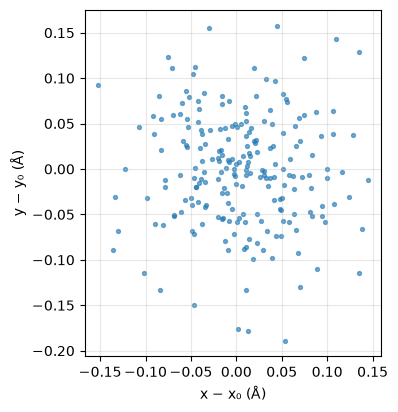

[PASS] the folded Sr cloud has the displacement width put in — 0.058 Å
[PASS] average cell = supercell / dimensions
[PASS] XYZ and CIF exports carry every atom


True

In [4]:
rng = np.random.default_rng(4)
thermal = rl.Box.from_rmc6f(sto)
thermal.frac = (thermal.frac + rng.normal(0, 0.06, thermal.frac.shape) / sto.cell[0]) % 1.0
tcfg = thermal.to_rmc6f(sto)
frac_cell, idx = rt.fold_to_unit_cell(tcfg)
sr = frac_cell[tcfg.atoms == "Sr"]
sr = sr - np.round(sr)                                   # the Sr site is at the origin: centre the cloud on it
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(sr[:, 0] * 3.905, sr[:, 1] * 3.905, s=8, alpha=0.6)
ax.set_xlabel("x − x₀ (Å)"); ax.set_ylabel("y − y₀ (Å)"); ax.set_aspect("equal")
show(fig)
caption("The 216 Sr atoms of the thermal SrTiO₃ box folded back into one unit cell and "
        "projected on the ab plane: a Gaussian cloud around the site whose width is the "
        "displacement amplitude put in (0.06 Å per coordinate).")
check("the folded Sr cloud has the displacement width put in", abs(sr[:, 0].std() * 3.905 - 0.06) < 0.012, f"{sr[:, 0].std() * 3.905:.3f} Å")
check("average cell = supercell / dimensions", rt.average_cell(tcfg)[:3] == (sto.cell[0] / 6,) * 3)

rt.export_xyz(tcfg, os.path.join(WORK, "sto.xyz"))
rt.export_cif(tcfg, os.path.join(WORK, "sto.cif"))
with open(os.path.join(WORK, "sto.xyz"), encoding="utf-8") as f:
    n_xyz = int(f.readline())
with open(os.path.join(WORK, "sto.cif"), encoding="utf-8") as f:
    cif = f.read()
check("XYZ and CIF exports carry every atom", n_xyz == 1080 and cif.count("_atom_site_fract_z") == 1 and "P 1" in cif)

<a id="sec-13"></a>

## 13. The .dat skeleton and the checker

The main control file (`.dat`, manual §4.1) names everything else. `DatFile` holds its
scalars, the `ATOMS ::` line and its keyword blocks in order and writes them back; `check_input_set`
then verifies what RMCProfile will trip on — a missing configuration, an atom order that
differs from the file, the wrong count of `MINIMUM_DISTANCES` (one per pair, AA AB AC BB BC
CC), a data file that is not there, a `.poly` the program would wait for forever. In the
package, `data2config` builds the configuration and a first `.dat` from a GSAS refinement;
`write_input_set` (chapter 4) does the same from a box and synthetic data.

In [5]:
dat = rt.DatFile()
for k, v in (("TITLE", "SrTiO3 skeleton"), ("NUMBER_DENSITY", f"{sto.density:.6f} Angstrom^(-3)"),
             ("MINIMUM_DISTANCES", "3.2 3.0 2.4 3.2 1.7 2.4 Angstrom"), ("MAXIMUM_MOVES", "0.05 0.05 0.1 Angstrom"),
             ("R_SPACING", "0.02 Angstrom"), ("PRINT_PERIOD", "100"), ("TIME_LIMIT", "0.00 MINUTES"), ("SAVE_PERIOD", "0.00 MINUTES")):
    dat.scalars[k] = v; dat.order.append(("scalar", k))
dat.atoms = ["Sr", "Ti", "O"]; dat.order.append(("atoms",))
dat.blocks.append(rt.DatBlock("FLAGS", "", [("NO_MOVEOUT", ""), ("NO_SAVE_CONFIGURATIONS", ""), ("NO_RESOLUTION_CONVOLUTION", "")]))
dat.order.append(("block", 0))
dat.scalars["INPUT_CONFIGURATION_FORMAT"] = "rmc6f"; dat.order.append(("scalar", "INPUT_CONFIGURATION_FORMAT"))
dat.write(os.path.join(WORK, "sto.dat"))
with open(os.path.join(WORK, "sto.dat"), encoding="utf-8") as f:
    print(f.read())
findings = rt.check_input_set("sto", WORK)
for fnd in findings:
    print(fnd.level, fnd.code, "-", fnd.message)
check("the skeleton passes the checker", not [x for x in findings if x.level == "ERROR"])

# break it on purpose: swap the atom order
dat.atoms = ["Ti", "Sr", "O"]; dat.write(os.path.join(WORK, "sto.dat"))
codes = [x.code for x in rt.check_input_set("sto", WORK) if x.level == "ERROR"]
check("a swapped ATOMS :: order is caught", "atom-order" in codes, str(codes))

TITLE :: SrTiO3 skeleton
NUMBER_DENSITY :: 0.083967 Angstrom^(-3)
MINIMUM_DISTANCES :: 3.2 3.0 2.4 3.2 1.7 2.4 Angstrom
MAXIMUM_MOVES :: 0.05 0.05 0.1 Angstrom
R_SPACING :: 0.02 Angstrom
PRINT_PERIOD :: 100
TIME_LIMIT :: 0.00 MINUTES
SAVE_PERIOD :: 0.00 MINUTES

ATOMS :: Sr Ti O


FLAGS ::
  > NO_MOVEOUT
  > NO_SAVE_CONFIGURATIONS
  > NO_RESOLUTION_CONVOLUTION
INPUT_CONFIGURATION_FORMAT :: rmc6f

END ::

INFO summary - sto: 0 data block(s), 3 atom type(s), 0 error(s)
[PASS] the skeleton passes the checker


[PASS] a swapped ATOMS :: order is caught — ['atom-order']


True

### Exercises for chapter 3

**3.1** Build a $4\times4\times4$ box of SrTiO$_3$ and compute how far in $r$ its partials can
be trusted (half the box). Would it serve neutron data measured to 20 Å?

**3.2** Write a `.dat` for it with a `MINIMUM_DISTANCES` line that has one value too few and
show the checker's verdict.

In [6]:
# 3.1 — half of 4 x 3.905 = 7.81 A: far too short for data to 20 A (one needs >= 11 x 11 x 11).
s4 = rt.build_configuration((3.905,) * 3 + (90,) * 3, STO, (4, 4, 4))
half = s4.cell[0] / 2
need = int(np.ceil(2 * 20.0 / 3.905))
print(f"4x4x4: half box {half:.2f} A; a 20 A range needs at least {need}x{need}x{need}")
check("3.1 a 4x4x4 SrTiO3 box reaches only 7.8 A", abs(half - 7.81) < 0.01 and need == 11)

# 3.2
dat.atoms = ["Sr", "Ti", "O"]; dat.scalars["MINIMUM_DISTANCES"] = "3.2 3.0 2.4 3.2 1.7 Angstrom"
s4.write(os.path.join(WORK, "s4.rmc6f")); dat.write(os.path.join(WORK, "s4.dat"))
codes = [x.code for x in rt.check_input_set("s4", WORK) if x.level == "ERROR"]
check("3.2 five distances for six pairs is an ERROR", codes == ["minimum-distances-count"], str(codes))

4x4x4: half box 7.81 A; a 20 A range needs at least 11x11x11
[PASS] 3.1 a 4x4x4 SrTiO3 box reaches only 7.8 A


[PASS] 3.2 five distances for six pairs is an ERROR — ['minimum-distances-count']


True

In [7]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 3 — checks passed : {_CHECKS['pass']}")
print(f"chapter 3 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 3 — checks passed : 14
chapter 3 — checks failed : 0
wall time                 : 1 s
Every quantitative claim in this notebook was verified in this run.
